# 03 - Évaluation et Export Mobile

Ce notebook permet d'évaluer les performances du modèle entraîné et de l'exporter pour un déploiement mobile.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

sys.path.append('../src')
from model import CurlClassifier
from utils import load_dataset
from export_mobile import export_to_torchscript, export_quantized_model

## 1. Chargement des données et du modèle

In [2]:
# Load data
X, y = load_dataset('../data')

# Transpose to (batch, channels, seq_len)
X = np.transpose(X, (0, 2, 1))

# Normalization
mean = X.mean(axis=(0, 2))
std = X.std(axis=(0, 2))
X = (X - mean[None, :, None]) / (std[None, :, None] + 1e-7)

X_torch = torch.tensor(X, dtype=torch.float32)

# Load model from TorchScript
model = torch.jit.load('../models_saved/curl_classifier.pt')
model.eval()

print(f"Model loaded from models_saved/curl_classifier.pt")
print(f"Data shape: {X_torch.shape}")
print(f"Class distribution: {np.bincount(y.astype(int))}")

Model loaded from models_saved/curl_classifier.pt
Data shape: torch.Size([125, 6, 100])
Class distribution: [39 86]


## 2. Inférence et Matrice de Confusion

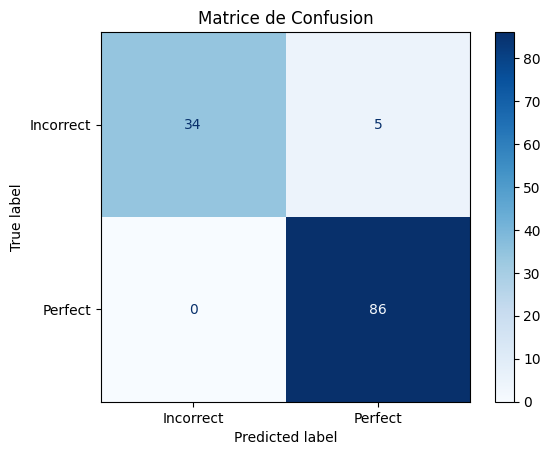

              precision    recall  f1-score   support

   Incorrect       1.00      0.87      0.93        39
     Perfect       0.95      1.00      0.97        86

    accuracy                           0.96       125
   macro avg       0.97      0.94      0.95       125
weighted avg       0.96      0.96      0.96       125



In [3]:
with torch.no_grad():
    outputs = model(X_torch)
    predictions = torch.argmax(outputs, dim=1).numpy()

cm = confusion_matrix(y, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Incorrect', 'Perfect'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matrice de Confusion")
plt.show()

print(classification_report(y, predictions, target_names=['Incorrect', 'Perfect']))

## 3. Export pour Mobile

Exportation du modèle en formats optimisés pour le déploiement mobile.

In [4]:
# Load the original model for quantization
model_py = CurlClassifier()

os.makedirs('../models_saved', exist_ok=True)

# TorchScript version (already done during training, but creating scripted version)
export_to_torchscript(model_py, '../models_saved/curl_classifier_scripted.pt')

# Quantized version
export_quantized_model(model_py, '../models_saved/curl_classifier_quant.pth')

print("\nExports completed successfully.")
print("Files saved:")
print("  - models_saved/curl_classifier.pt (TorchScript - best model from training)")
print("  - models_saved/curl_classifier_scripted.pt (Optimized TorchScript)")
print("  - models_saved/curl_classifier_quant.pth (Quantized INT8)")

Model exported and optimized for mobile: ../models_saved/curl_classifier_scripted.pt
Quantized model state dict saved: ../models_saved/curl_classifier_quant.pth

Exports completed successfully.
Files saved:
  - models_saved/curl_classifier.pt (TorchScript - best model from training)
  - models_saved/curl_classifier_scripted.pt (Optimized TorchScript)
  - models_saved/curl_classifier_quant.pth (Quantized INT8)


# 03 - Évaluation et Export

Ce notebook permet d'évaluer les performances du modèle et de l'exporter pour un déploiement mobile.

In [5]:
import torch
import numpy as np
import sys
import os
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

sys.path.append('../src')
from model import CurlClassifier
from utils import load_dataset
from export_mobile import export_to_torchscript, export_quantized_model

## 1. Chargement des données et du modèle

In [7]:
base_path = '../data'
X, y = load_dataset(base_path)

# Transpose and normalize
X = np.transpose(X, (0, 2, 1))
mean = X.mean(axis=(0, 2))
std = X.std(axis=(0, 2))
X = (X - mean[None, :, None]) / (std[None, :, None] + 1e-7)

X_torch = torch.tensor(X, dtype=torch.float32)

# Load TorchScript model directly
model = torch.jit.load('../models_saved/curl_classifier.pt')
model.eval()

print(f"Model loaded from models_saved/curl_classifier.pt (TorchScript)")
print(f"Data shape: {X_torch.shape}")
print(f"Class distribution: {np.bincount(y.astype(int))}")

Model loaded from models_saved/curl_classifier.pt (TorchScript)
Data shape: torch.Size([125, 6, 100])
Class distribution: [39 86]


## 2. Inférence et Matrice de Confusion

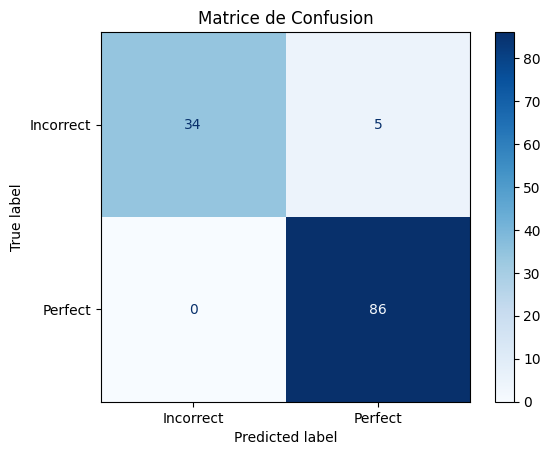

              precision    recall  f1-score   support

   Incorrect       1.00      0.87      0.93        39
     Perfect       0.95      1.00      0.97        86

    accuracy                           0.96       125
   macro avg       0.97      0.94      0.95       125
weighted avg       0.96      0.96      0.96       125

Accuracy: 0.9600


In [8]:
with torch.no_grad():
    outputs = model(X_torch)
    predictions = torch.argmax(outputs, dim=1).numpy()

cm = confusion_matrix(y, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Incorrect', 'Perfect'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matrice de Confusion")
plt.show()

print(classification_report(y, predictions, target_names=['Incorrect', 'Perfect']))
print(f"Accuracy: {np.mean(predictions == y):.4f}")

## 3. Export Mobile

Conversion vers TorchScript et Quantification INT8.

In [9]:
os.makedirs('../models_saved', exist_ok=True)

# Export TorchScript version (already done during training, but creating additional versions)
export_to_torchscript(model, '../models_saved/curl_classifier_scripted.pt')

# Export quantized version
export_quantized_model(model, '../models_saved/curl_classifier_quant.pth')

print("All exports completed successfully.")
print("Files saved:")
print("  - models_saved/curl_classifier.pt (TorchScript - best model from training)")
print("  - models_saved/curl_classifier_scripted.pt (Optimized TorchScript)")
print("  - models_saved/curl_classifier_quant.pth (Quantized INT8)")

Model exported and optimized for mobile: ../models_saved/curl_classifier_scripted.pt
Quantized model state dict saved: ../models_saved/curl_classifier_quant.pth
All exports completed successfully.
Files saved:
  - models_saved/curl_classifier.pt (TorchScript - best model from training)
  - models_saved/curl_classifier_scripted.pt (Optimized TorchScript)
  - models_saved/curl_classifier_quant.pth (Quantized INT8)


/usr/local/lib/python3.10/site-packages/torch/jit/_trace.py:1022: UserWarning: The input to trace is already a ScriptModule, tracing it is a no-op. Returning the object as is.
  traced_func = _trace_impl(
